# Dueling DQN Experiments

## Installs & Imports

In [1]:
import numpy as np
import pandas as pd
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.monitor import load_results
from stable_baselines3.common.results_plotter import ts2xy
from stable_baselines3.common.callbacks import EvalCallback
from dueling_dqn import DuelingDQN
from RewardWrapper import DistancePenaltyWrapper

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
final_seeds = [42, 84, 146, 1447, 2026]

## Baseline Scenario

### Training Dueling DQN

In [ ]:

all_results = []

for seed in final_seeds:
    print(f"\n=== Training Dueling DQN with seed={seed} ===")

    train_env = gym.make("LunarLander-v3")
    train_env = Monitor(train_env, f"baseline_scenario/dueling_dqn/dueling_dqn_seed_{seed}_log")

    eval_env = gym.make("LunarLander-v3")
    
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=f"baseline_scenario/dueling_dqn/best_dueling_dqn_seed_{seed}/",
        log_path=f"baseline_scenario/dueling_dqn/eval_logs_seed_{seed}/",
        eval_freq=10_000,
        n_eval_episodes=5,
        deterministic=True
    )

    model = DuelingDQN(
        "MlpPolicy",
        train_env,
        learning_rate=1e-4,
        gamma=0.99,
        exploration_fraction=0.5,
        target_update_interval=1000,
        batch_size= 64,
        buffer_size= 100_000,
        policy_kwargs=dict(net_arch=[128, 128]),
        verbose=0,
        seed=seed,
    )

    model.learn(total_timesteps=1_000_000, callback=eval_callback)
    
    model.save(f"baseline_scenario/dueling_dqn/dueling_dqn_lunarlander_seed_{seed}")

    best_model = DuelingDQN.load(f"baseline_scenario/dueling_dqn/best_dueling_dqn_seed_{seed}/best_model")
    mean_reward, std_reward = evaluate_policy(best_model, eval_env, n_eval_episodes=20)

    print(f"Seed {seed} -> Best model reward: {mean_reward:.2f} +/- {std_reward:.2f}")
    all_results.append(mean_reward)

all_results = np.array(all_results)
print(f"\n=== Final Result Across {len(final_seeds)} Seeds (Dueling DQN) ===")
print(f"Mean: {all_results.mean():.2f} +/- {all_results.std():.2f}")


=== Training Dueling DQN with seed=42 ===


d:\Queen's\Reinforcement Learning\Project\rlenv\Lib\site-packages\stable_baselines3\common\evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=10000, episode_reward=-111.74 +/- 15.25
Episode length: 954.00 +/- 92.00
New best mean reward!
Eval num_timesteps=20000, episode_reward=-167.38 +/- 22.65
Episode length: 875.20 +/- 156.90
Eval num_timesteps=30000, episode_reward=-210.24 +/- 52.97
Episode length: 801.80 +/- 173.75
Eval num_timesteps=40000, episode_reward=-36.43 +/- 92.45
Episode length: 701.80 +/- 303.21
New best mean reward!
Eval num_timesteps=50000, episode_reward=-96.33 +/- 16.95
Episode length: 765.00 +/- 299.77
Eval num_timesteps=60000, episode_reward=-139.47 +/- 26.61
Episode length: 417.00 +/- 139.20
Eval num_timesteps=70000, episode_reward=-162.67 +/- 26.02
Episode length: 468.60 +/- 181.27
Eval num_timesteps=80000, episode_reward=-144.20 +/- 39.46
Episode length: 261.20 +/- 127.86
Eval num_timesteps=90000, episode_reward=-188.53 +/- 22.02
Episode length: 403.40 +/- 73.26
Eval num_timesteps=100000, episode_reward=-158.22 +/- 60.48
Episode length: 679.60 +/- 264.73
Eval num_timesteps=110000, ep

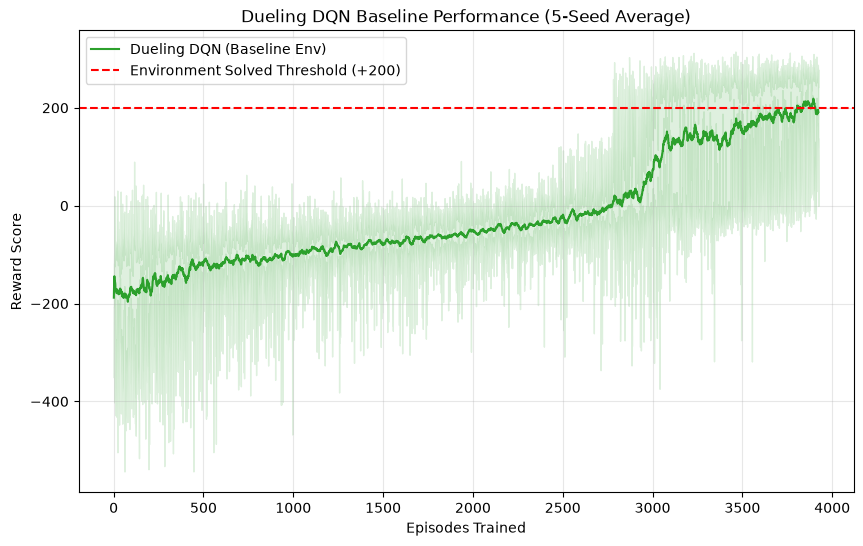

In [ ]:
all_rewards_per_seed = []

for seed in final_seeds:
    data = pd.read_csv(f"baseline_scenario/dueling_dqn/dueling_dqn_seed_{seed}_log.monitor.csv", skiprows=1)
    data['timesteps'] = data['l'].cumsum()
    all_rewards_per_seed.append(data['r'].values)

min_len = min(len(r) for r in all_rewards_per_seed)
all_rewards_per_seed = np.array([r[:min_len] for r in all_rewards_per_seed])

episodes = np.arange(1, min_len + 1)

mean_across_seeds = all_rewards_per_seed.mean(axis=0)
min_across_seeds = all_rewards_per_seed.min(axis=0)
max_across_seeds = all_rewards_per_seed.max(axis=0)

window = 20
mean_smooth = pd.Series(mean_across_seeds).rolling(window, min_periods=1).mean()

plt.figure(figsize=(10, 6))
plt.plot(episodes, mean_smooth, label="Dueling DQN (Baseline Env)", color="tab:green")
plt.fill_between(episodes, min_across_seeds, max_across_seeds, alpha=0.15, color="tab:green")
plt.axhline(y=200, color="red", linestyle="--", label="Environment Solved Threshold (+200)")
plt.xlabel("Episodes Trained")
plt.ylabel("Reward Score")
plt.title("Dueling DQN Baseline Performance (5-Seed Average)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Testing Dueling DQN Best Models

In [3]:
NUM_EVAL_EPISODES = 100

all_seed_mean_rewards = []
all_seed_success_rates = []
all_seed_crash_rates = []

all_test_rewards_data = {}

env = gym.make("LunarLander-v3")

print(" Starting 5-Seed evaluation ...\n")

for seed in final_seeds:
    model_path = f"baseline_scenario/dueling_dqn/best_dueling_dqn_seed_{seed}/best_model.zip"
    model = DuelingDQN.load(model_path, env=env)
    
    seed_rewards = []
    successes = 0
    crashes = 0
    
    for ep in range(NUM_EVAL_EPISODES):
        obs, _ = env.reset()
        done = False
        truncated = False
        total_reward = 0
        
        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            total_reward += reward
            
            if done or truncated:
                lander_body = env.unwrapped.lander
                is_game_over = env.unwrapped.game_over
                helipad_x1 = env.unwrapped.helipad_x1
                helipad_x2 = env.unwrapped.helipad_x2
                
                lander_x = lander_body.position.x
                
                on_pad = helipad_x1 <= lander_x <= helipad_x2
                
                if is_game_over or abs(obs[0]) >= 1.0:
                    crashes += 1
                elif (not lander_body.awake) and on_pad:
                    successes += 1
                    
        seed_rewards.append(total_reward)
    
    seed_mean_reward = np.mean(seed_rewards)
    seed_success_rate = (successes / NUM_EVAL_EPISODES) * 100
    seed_crash_rate = (crashes / NUM_EVAL_EPISODES) * 100
    
    all_seed_mean_rewards.append(seed_mean_reward)
    all_seed_success_rates.append(seed_success_rate)
    all_seed_crash_rates.append(seed_crash_rate)
    all_test_rewards_data[f"Seed {seed}"] = seed_rewards
    
    print(f" Seed {seed} raw metrics:")
    print(f"Mean Reward: {seed_mean_reward:.2f}")
    print(f"Success Rate: {seed_success_rate:.1f}%")
    print(f"Crash Rate: {seed_crash_rate:.1f}%\n")

env.close()

final_reward_mean = np.mean(all_seed_mean_rewards)
final_reward_std = np.std(all_seed_mean_rewards)
final_success_mean = np.mean(all_seed_success_rates)
final_crash_mean = np.mean(all_seed_crash_rates)

print(" Final 5-seed metrics averages(Dueling DQN - Baseline):")
print(f"Overall Mean Reward: {final_reward_mean:.2f} +/- {final_reward_std:.2f}")
print(f"Overall Success Rate: {final_success_mean:.1f}%")
print(f"Overall Crash Rate: {final_crash_mean:.1f}%")

 Starting 5-Seed evaluation ...

 Seed 42 raw metrics:
Mean Reward: 206.14
Success Rate: 55.0%
Crash Rate: 2.0%

 Seed 84 raw metrics:
Mean Reward: 100.42
Success Rate: 27.0%
Crash Rate: 5.0%

 Seed 146 raw metrics:
Mean Reward: 178.46
Success Rate: 44.0%
Crash Rate: 2.0%

 Seed 1447 raw metrics:
Mean Reward: 241.40
Success Rate: 71.0%
Crash Rate: 2.0%

 Seed 2026 raw metrics:
Mean Reward: 224.41
Success Rate: 83.0%
Crash Rate: 3.0%

 Final 5-seed metrics averages(Dueling DQN - Baseline):
Overall Mean Reward: 190.17 +/- 49.48
Overall Success Rate: 56.0%
Overall Crash Rate: 2.8%


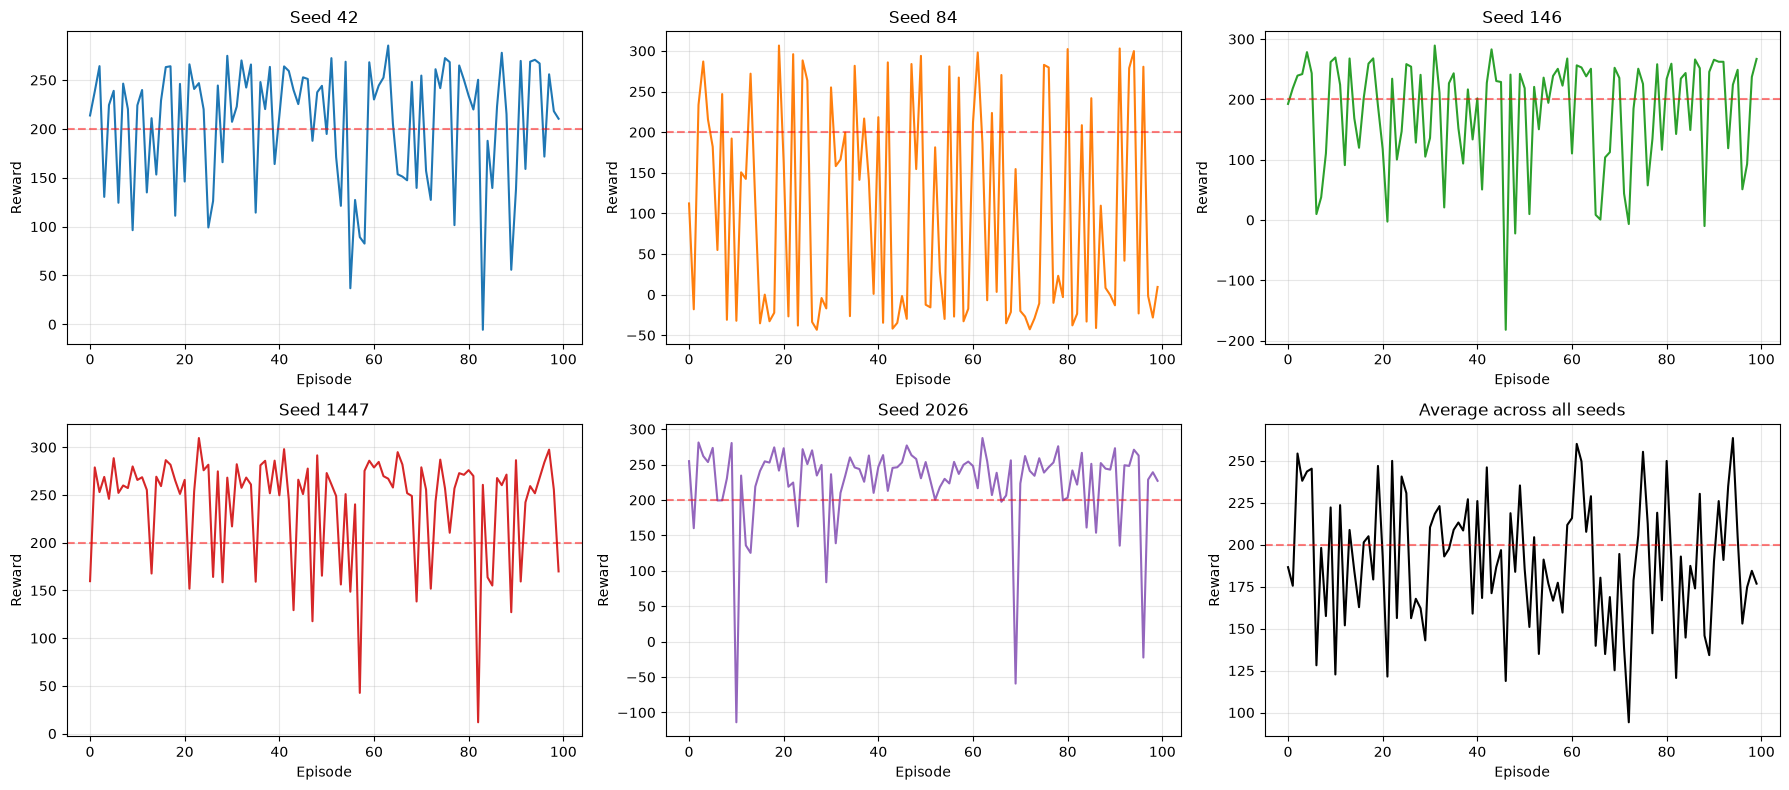

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

seed_names = list(all_test_rewards_data.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, seed_name in enumerate(seed_names):
    rewards = all_test_rewards_data[seed_name]
    axes[i].plot(rewards, color=colors[i])
    axes[i].axhline(y=200, color='red', linestyle='--', alpha=0.5)
    axes[i].set_title(seed_name)
    axes[i].set_xlabel("Episode")
    axes[i].set_ylabel("Reward")
    axes[i].grid(True, alpha=0.3)

avg_rewards = np.mean([all_test_rewards_data[s] for s in seed_names], axis=0)
axes[5].plot(avg_rewards, color='black')
axes[5].axhline(y=200, color='red', linestyle='--', alpha=0.5)
axes[5].set_title("Average across all seeds")
axes[5].set_xlabel("Episode")
axes[5].set_ylabel("Reward")
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

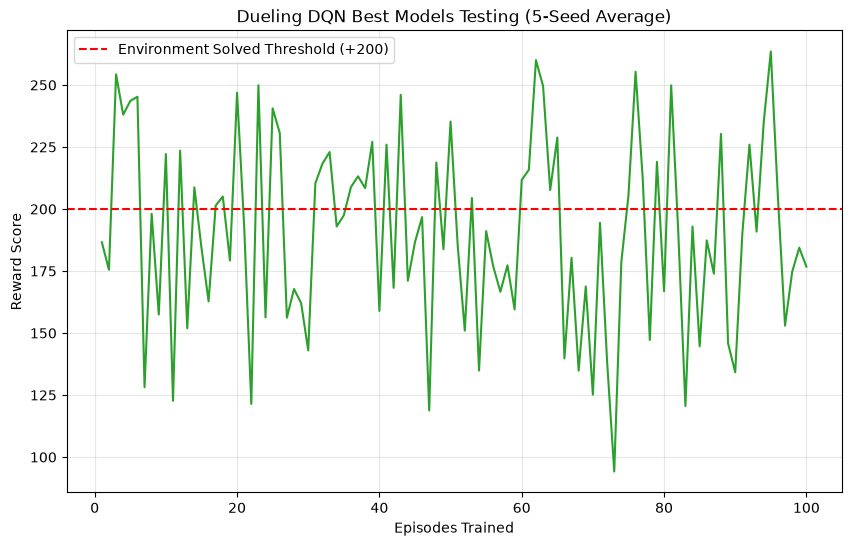

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, NUM_EVAL_EPISODES + 1), avg_rewards, color="tab:green")
plt.axhline(y=200, color="red", linestyle="--", label="Environment Solved Threshold (+200)")
plt.xlabel("Episodes Trained")
plt.ylabel("Reward Score")
plt.title("Dueling DQN Best Models Testing (5-Seed Average)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

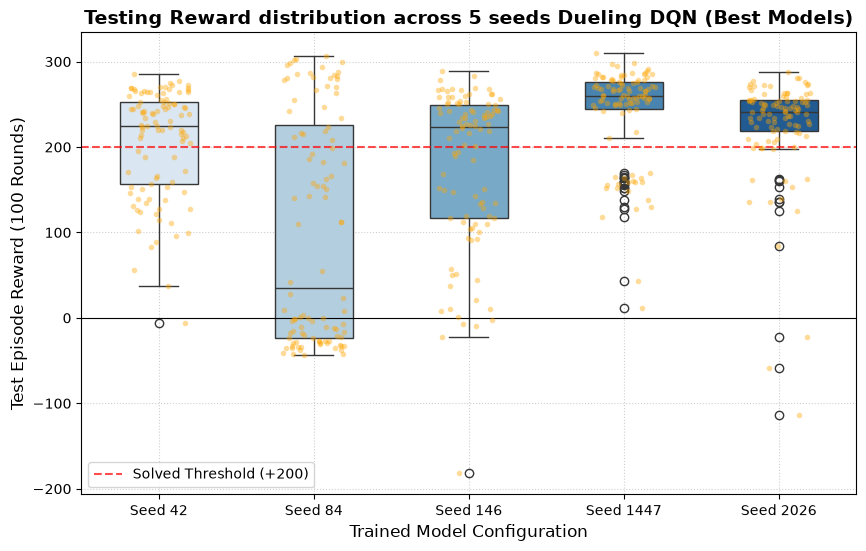

In [6]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=list(all_test_rewards_data.values()), palette="Blues", width=0.5)
sns.stripplot(data=list(all_test_rewards_data.values()), color="orange", alpha=0.4, size=4, jitter=0.2)

plt.xticks(ticks=range(len(final_seeds)), labels=list(all_test_rewards_data.keys()))

plt.axhline(y=200, color='red', linestyle='--', alpha=0.7, label='Solved Threshold (+200)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.title("Testing Reward distribution across 5 seeds Dueling DQN (Best Models)", fontsize=14, fontweight='bold')
plt.xlabel("Trained Model Configuration", fontsize=12)
plt.ylabel("Test Episode Reward (100 Rounds)", fontsize=12)
plt.legend(loc="lower left")
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

## Reward Shapping Modfication Senario

### Training Model

In [ ]:

all_results = []

for seed in final_seeds:
    print(f"\n=== Training Dueling DQN with seed={seed} ===")

    train_env = gym.make("LunarLander-v3")
    train_env = DistancePenaltyWrapper(train_env, penalty_weight=0.1)
    train_env = Monitor(train_env, f"reward_shpping_scenario/dueling_dqn/dueling_dqn_seed_{seed}_log")

    eval_env = gym.make("LunarLander-v3")
    eval_env = DistancePenaltyWrapper(eval_env, penalty_weight=0.1)
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=f"reward_shpping_scenario/dueling_dqn/best_dueling_dqn_seed_{seed}/",
        log_path=f"reward_shpping_scenario/dueling_dqn/eval_logs_seed_{seed}/",
        eval_freq=10_000,
        n_eval_episodes=5,
        deterministic=True
    )

    model = DuelingDQN(
        "MlpPolicy",
        train_env,
        learning_rate=1e-4,
        gamma=0.99,
        exploration_fraction=0.5,
        target_update_interval=1000,
        batch_size= 64,
        buffer_size= 100_000,
        policy_kwargs=dict(net_arch=[128, 128]),
        verbose=0,
        seed=seed,
    )

    model.learn(total_timesteps=1_000_000, callback=eval_callback)
    
    model.save(f"reward_shpping_scenario/dueling_dqn/dueling_dqn_lunarlander_seed_{seed}")

    best_model = DuelingDQN.load(f"reward_shpping_scenario/dueling_dqn/best_dueling_dqn_seed_{seed}/best_model")
    mean_reward, std_reward = evaluate_policy(best_model, eval_env, n_eval_episodes=20)

    print(f"Seed {seed} -> Best model reward: {mean_reward:.2f} +/- {std_reward:.2f}")
    all_results.append(mean_reward)

all_results = np.array(all_results)
print(f"\n=== Final Result Across {len(final_seeds)} Seeds (Dueling DQN + Reward Shapping) ===")
print(f"Mean: {all_results.mean():.2f} +/- {all_results.std():.2f}")


=== Training Dueling DQN with seed=42 ===
Eval num_timesteps=10000, episode_reward=-134.73 +/- 104.89
Episode length: 609.20 +/- 335.51
New best mean reward!
Eval num_timesteps=20000, episode_reward=-267.39 +/- 26.44
Episode length: 964.00 +/- 72.00
Eval num_timesteps=30000, episode_reward=-244.42 +/- 5.53
Episode length: 876.60 +/- 154.34
Eval num_timesteps=40000, episode_reward=-247.37 +/- 34.41
Episode length: 643.60 +/- 194.06
Eval num_timesteps=50000, episode_reward=-113.52 +/- 20.94
Episode length: 831.80 +/- 336.40
New best mean reward!
Eval num_timesteps=60000, episode_reward=-147.45 +/- 34.23
Episode length: 1000.00 +/- 0.00
Eval num_timesteps=70000, episode_reward=-171.27 +/- 28.51
Episode length: 539.60 +/- 391.76
Eval num_timesteps=80000, episode_reward=-182.71 +/- 31.84
Episode length: 339.20 +/- 159.23
Eval num_timesteps=90000, episode_reward=-209.21 +/- 40.24
Episode length: 324.20 +/- 122.13
Eval num_timesteps=100000, episode_reward=-222.54 +/- 20.71
Episode length: 43

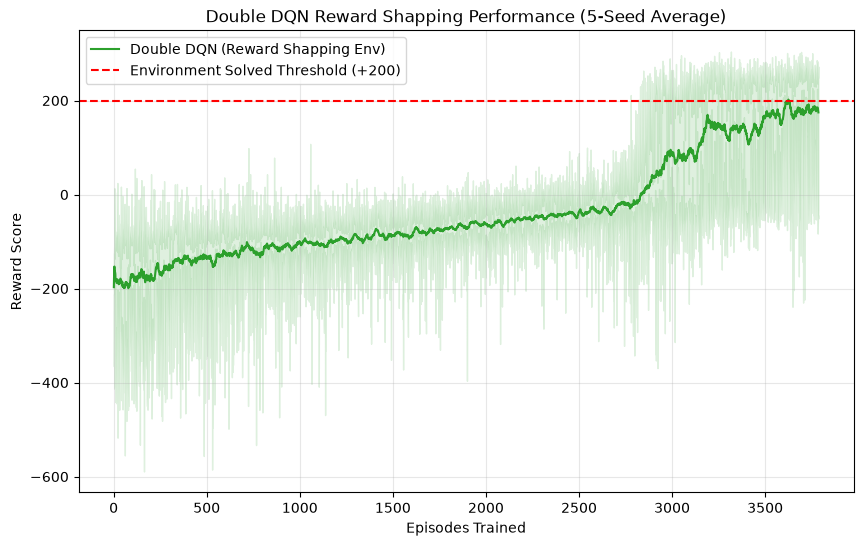

In [ ]:
all_rewards_per_seed = []

for seed in final_seeds:
    data = pd.read_csv(f"reward_shpping_scenario/dueling_dqn/dueling_dqn_seed_{seed}_log.monitor.csv", skiprows=1)
    data['timesteps'] = data['l'].cumsum()
    all_rewards_per_seed.append(data['r'].values)

min_len = min(len(r) for r in all_rewards_per_seed)
all_rewards_per_seed = np.array([r[:min_len] for r in all_rewards_per_seed])

episodes = np.arange(1, min_len + 1)

mean_across_seeds = all_rewards_per_seed.mean(axis=0)
min_across_seeds = all_rewards_per_seed.min(axis=0)
max_across_seeds = all_rewards_per_seed.max(axis=0)

window = 20
mean_smooth = pd.Series(mean_across_seeds).rolling(window, min_periods=1).mean()

plt.figure(figsize=(10, 6))
plt.plot(episodes, mean_smooth, label="Double DQN (Reward Shapping Env)", color="tab:green")
plt.fill_between(episodes, min_across_seeds, max_across_seeds, alpha=0.15, color="tab:green")
plt.axhline(y=200, color="red", linestyle="--", label="Environment Solved Threshold (+200)")
plt.xlabel("Episodes Trained")
plt.ylabel("Reward Score")
plt.title("Double DQN Reward Shapping Performance (5-Seed Average)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Testing Model

In [4]:
NUM_EVAL_EPISODES = 100

all_seed_mean_rewards = []
all_seed_success_rates = []
all_seed_crash_rates = []

all_test_rewards_data = {}

env = gym.make("LunarLander-v3")
env = DistancePenaltyWrapper(env, penalty_weight=0.1)

print(" Starting 5-Seed evaluation ...\n")

for seed in final_seeds:
    model_path = f"reward_shpping_scenario/dueling_dqn/best_dueling_dqn_seed_{seed}/best_model.zip"
    model = DuelingDQN.load(model_path, env=env)
    
    seed_rewards = []
    successes = 0
    crashes = 0
    
    for ep in range(NUM_EVAL_EPISODES):
        obs, _ = env.reset()
        done = False
        truncated = False
        total_reward = 0

        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            total_reward += reward

            if done or truncated:
                lander_body = env.unwrapped.lander
                is_game_over = env.unwrapped.game_over
                helipad_x1 = env.unwrapped.helipad_x1
                helipad_x2 = env.unwrapped.helipad_x2
                
                lander_x = lander_body.position.x
                
                on_pad = helipad_x1 <= lander_x <= helipad_x2
                
                if is_game_over or abs(obs[0]) >= 1.0:
                    crashes += 1
                elif (not lander_body.awake) and on_pad:
                    successes += 1

        seed_rewards.append(total_reward)
    
    seed_mean_reward = np.mean(seed_rewards)
    seed_success_rate = (successes / NUM_EVAL_EPISODES) * 100
    seed_crash_rate = (crashes / NUM_EVAL_EPISODES) * 100
    
    all_seed_mean_rewards.append(seed_mean_reward)
    all_seed_success_rates.append(seed_success_rate)
    all_seed_crash_rates.append(seed_crash_rate)
    all_test_rewards_data[f"Seed {seed}"] = seed_rewards
    
    print(f" Seed {seed} raw metrics:")
    print(f"Mean Reward: {seed_mean_reward:.2f}")
    print(f"Success Rate: {seed_success_rate:.1f}%")
    print(f"Crash Rate: {seed_crash_rate:.1f}%\n")

env.close()

final_reward_mean = np.mean(all_seed_mean_rewards)
final_reward_std = np.std(all_seed_mean_rewards)
final_success_mean = np.mean(all_seed_success_rates)
final_crash_mean = np.mean(all_seed_crash_rates)

print(" Final 5-seed metrics averages(Dueling DQN - Reward Shaping):")
print(f"Overall Mean Reward: {final_reward_mean:.2f} +/- {final_reward_std:.2f}")
print(f"Overall Success Rate: {final_success_mean:.1f}%")
print(f"Overall Crash Rate: {final_crash_mean:.1f}%")

 Starting 5-Seed evaluation ...

 Seed 42 raw metrics:
Mean Reward: 150.56
Success Rate: 37.0%
Crash Rate: 6.0%

 Seed 84 raw metrics:
Mean Reward: 144.96
Success Rate: 47.0%
Crash Rate: 5.0%

 Seed 146 raw metrics:
Mean Reward: 164.57
Success Rate: 42.0%
Crash Rate: 8.0%

 Seed 1447 raw metrics:
Mean Reward: 235.21
Success Rate: 84.0%
Crash Rate: 4.0%

 Seed 2026 raw metrics:
Mean Reward: 208.81
Success Rate: 80.0%
Crash Rate: 5.0%

 Final 5-seed metrics averages(Dueling DQN - Reward Shaping):
Overall Mean Reward: 180.82 +/- 35.24
Overall Success Rate: 58.0%
Overall Crash Rate: 5.6%


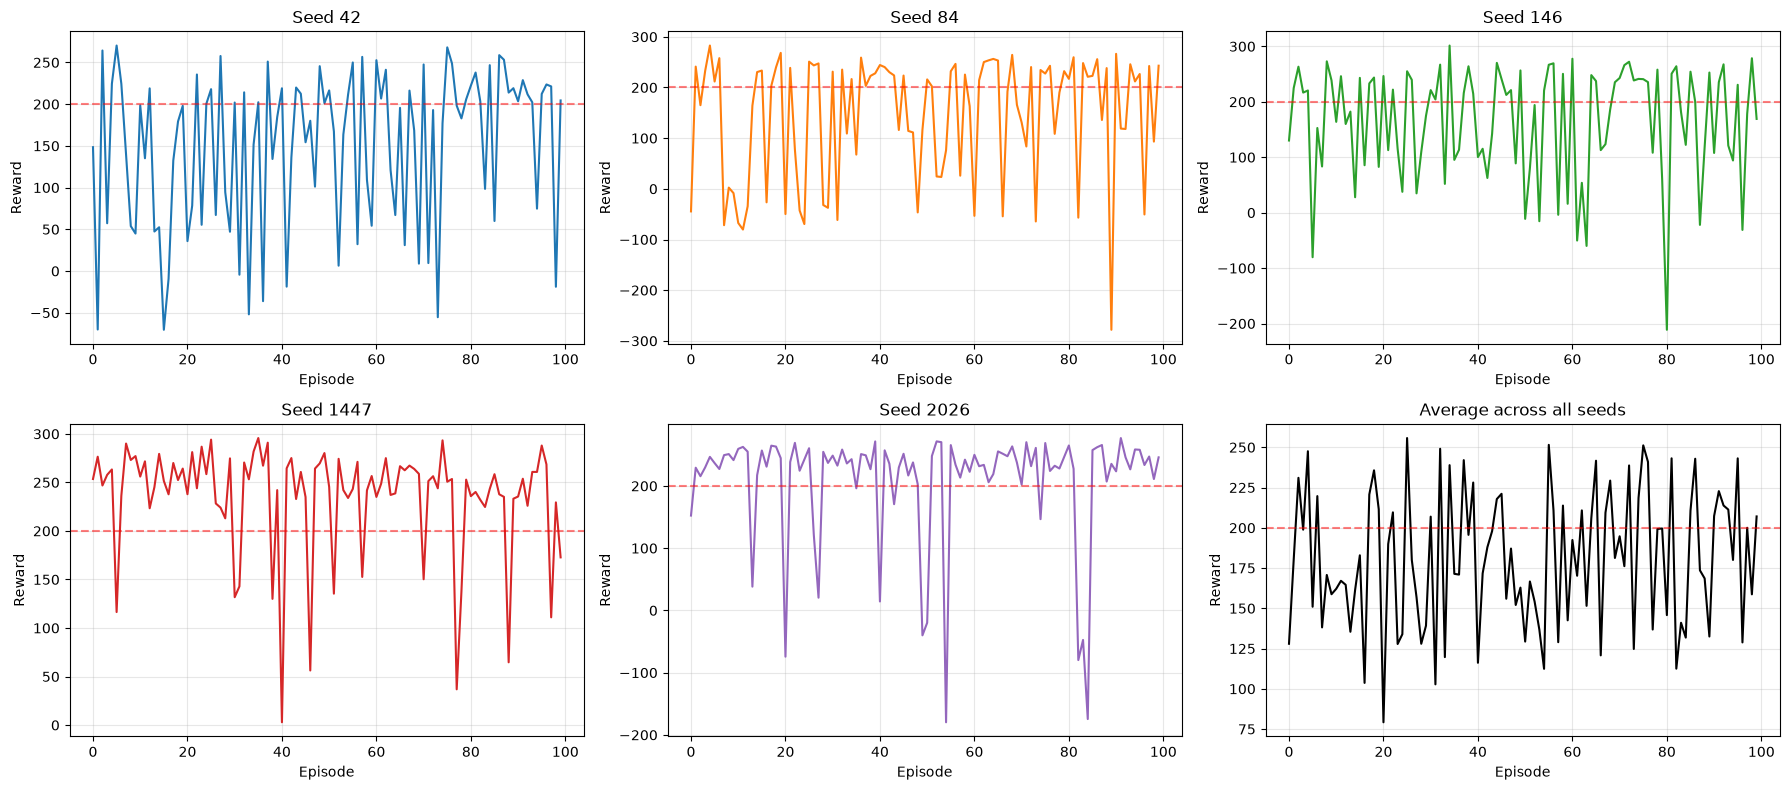

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

seed_names = list(all_test_rewards_data.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, seed_name in enumerate(seed_names):
    rewards = all_test_rewards_data[seed_name]
    axes[i].plot(rewards, color=colors[i])
    axes[i].axhline(y=200, color='red', linestyle='--', alpha=0.5)
    axes[i].set_title(seed_name)
    axes[i].set_xlabel("Episode")
    axes[i].set_ylabel("Reward")
    axes[i].grid(True, alpha=0.3)

avg_rewards = np.mean([all_test_rewards_data[s] for s in seed_names], axis=0)
axes[5].plot(avg_rewards, color='black')
axes[5].axhline(y=200, color='red', linestyle='--', alpha=0.5)
axes[5].set_title("Average across all seeds")
axes[5].set_xlabel("Episode")
axes[5].set_ylabel("Reward")
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

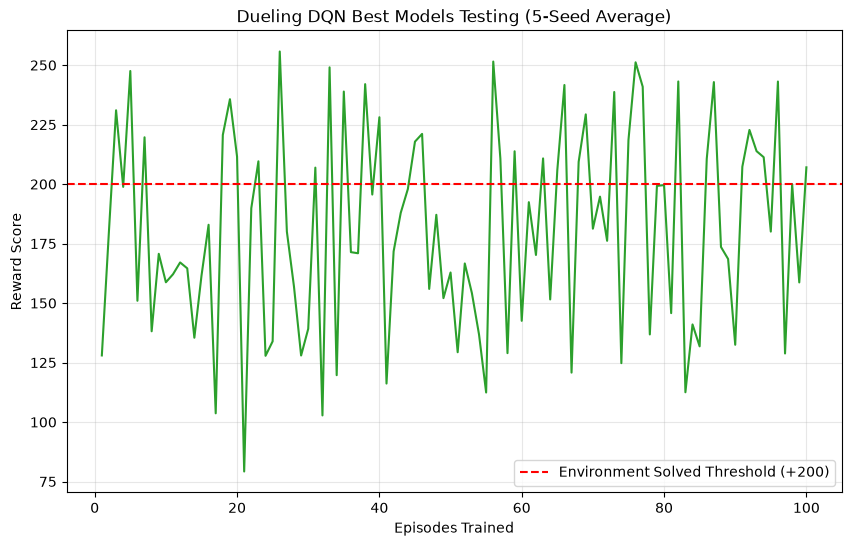

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, NUM_EVAL_EPISODES + 1), avg_rewards, color="tab:green")
plt.axhline(y=200, color="red", linestyle="--", label="Environment Solved Threshold (+200)")
plt.xlabel("Episodes Trained")
plt.ylabel("Reward Score")
plt.title("Dueling DQN Best Models Testing (5-Seed Average)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

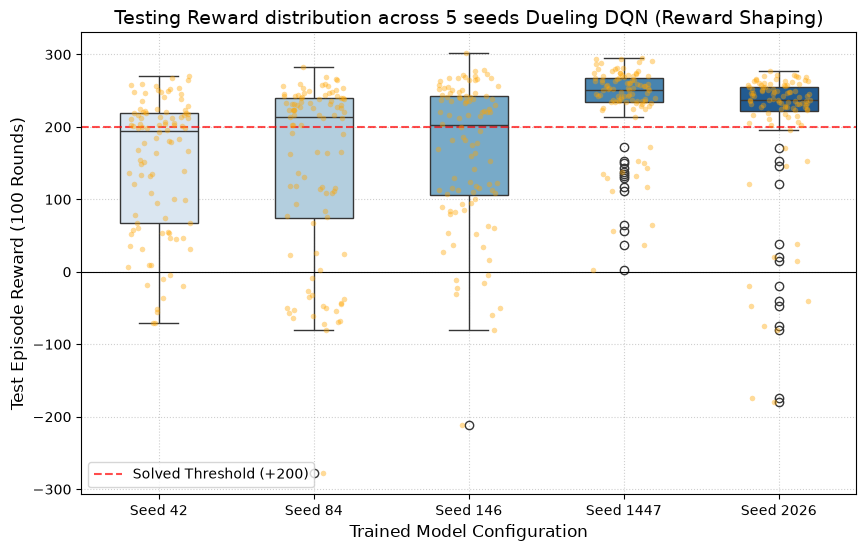

In [7]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=list(all_test_rewards_data.values()), palette="Blues", width=0.5)
sns.stripplot(data=list(all_test_rewards_data.values()), color="orange", alpha=0.4, size=4, jitter=0.2)

plt.xticks(ticks=range(len(final_seeds)), labels=list(all_test_rewards_data.keys()))

plt.axhline(y=200, color='red', linestyle='--', alpha=0.7, label='Solved Threshold (+200)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.title("Testing Reward distribution across 5 seeds Dueling DQN (Reward Shaping)", fontsize=14)
plt.xlabel("Trained Model Configuration", fontsize=12)
plt.ylabel("Test Episode Reward (100 Rounds)", fontsize=12)
plt.legend(loc="lower left")
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

## Wind Power Env Modifiaction

### Model Training

In [ ]:

all_results = []

for seed in final_seeds:
    print(f"\n=== Training Dueling DQN with seed={seed} ===")

    train_env = gym.make("LunarLander-v3", wind_power=15.0, turbulence_power=1.5, enable_wind=True)
    train_env = Monitor(train_env, f"wind_scenario/dueling_dqn/dueling_dqn_seed_{seed}_log")

    eval_env = gym.make("LunarLander-v3", wind_power=15.0, turbulence_power=1.5, enable_wind=True)
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=f"wind_scenario/dueling_dqn/best_dueling_dqn_seed_{seed}/",
        log_path=f"wind_scenario/dueling_dqn/eval_logs_seed_{seed}/",
        eval_freq=10_000,
        n_eval_episodes=5,
        deterministic=True
    )

    model = DuelingDQN(
        "MlpPolicy",
        train_env,
        learning_rate=1e-4,
        gamma=0.99,
        exploration_fraction=0.5,
        target_update_interval=1000,
        batch_size= 64,
        buffer_size= 100_000,
        policy_kwargs=dict(net_arch=[128, 128]),
        verbose=0,
        seed=seed,
    )

    model.learn(total_timesteps=1_000_000, callback=eval_callback)
    
    model.save(f"wind_scenario/dueling_dqn/dueling_dqn_lunarlander_seed_{seed}")

    best_model = DuelingDQN.load(f"wind_scenario/dueling_dqn/best_dueling_dqn_seed_{seed}/best_model")
    mean_reward, std_reward = evaluate_policy(best_model, eval_env, n_eval_episodes=20)

    print(f"Seed {seed} -> Best model reward: {mean_reward:.2f} +/- {std_reward:.2f}")
    all_results.append(mean_reward)

all_results = np.array(all_results)
print(f"\n=== Final Result Across {len(final_seeds)} Seeds (Dueling DQN) ===")
print(f"Mean: {all_results.mean():.2f} +/- {all_results.std():.2f}")


=== Training Dueling DQN with seed=42 ===
Eval num_timesteps=10000, episode_reward=-147.96 +/- 31.20
Episode length: 832.60 +/- 334.80
New best mean reward!
Eval num_timesteps=20000, episode_reward=-180.23 +/- 52.74
Episode length: 598.00 +/- 273.61
Eval num_timesteps=30000, episode_reward=-217.02 +/- 24.17
Episode length: 367.20 +/- 102.03
Eval num_timesteps=40000, episode_reward=-168.76 +/- 24.60
Episode length: 228.00 +/- 75.72
Eval num_timesteps=50000, episode_reward=-109.29 +/- 147.00
Episode length: 416.60 +/- 322.54
New best mean reward!
Eval num_timesteps=60000, episode_reward=-127.04 +/- 42.56
Episode length: 257.40 +/- 97.99
Eval num_timesteps=70000, episode_reward=-136.25 +/- 54.40
Episode length: 142.00 +/- 51.24
Eval num_timesteps=80000, episode_reward=-103.31 +/- 61.23
Episode length: 119.60 +/- 37.49
New best mean reward!
Eval num_timesteps=90000, episode_reward=-118.93 +/- 37.32
Episode length: 111.60 +/- 30.90
Eval num_timesteps=100000, episode_reward=-151.18 +/- 79.4

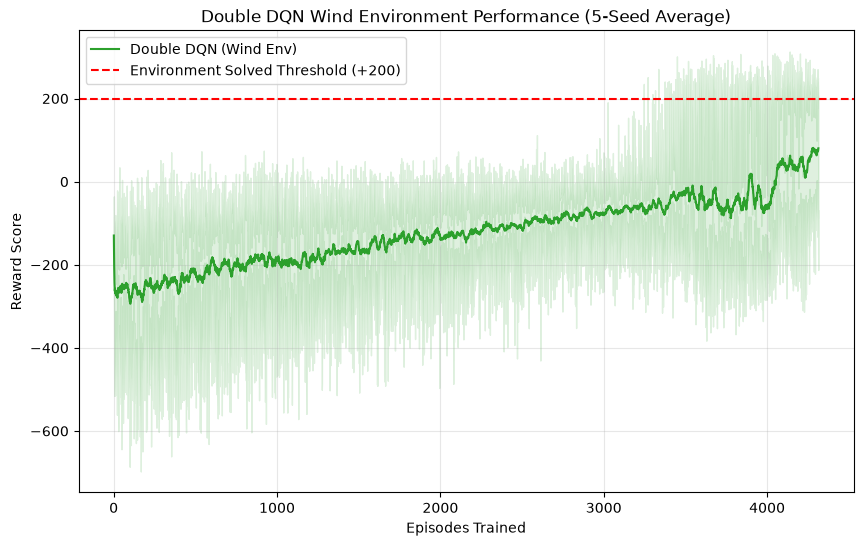

In [ ]:
all_rewards_per_seed = []

for seed in final_seeds:
    data = pd.read_csv(f"wind_scenario/dueling_dqn/dueling_dqn_seed_{seed}_log.monitor.csv", skiprows=1)
    data['timesteps'] = data['l'].cumsum()
    all_rewards_per_seed.append(data['r'].values)

min_len = min(len(r) for r in all_rewards_per_seed)
all_rewards_per_seed = np.array([r[:min_len] for r in all_rewards_per_seed])

episodes = np.arange(1, min_len + 1)

mean_across_seeds = all_rewards_per_seed.mean(axis=0)
min_across_seeds = all_rewards_per_seed.min(axis=0)
max_across_seeds = all_rewards_per_seed.max(axis=0)

window = 20
mean_smooth = pd.Series(mean_across_seeds).rolling(window, min_periods=1).mean()

plt.figure(figsize=(10, 6))
plt.plot(episodes, mean_smooth, label="Double DQN (Wind Env)", color="tab:green")
plt.fill_between(episodes, min_across_seeds, max_across_seeds, alpha=0.15, color="tab:green")
plt.axhline(y=200, color="red", linestyle="--", label="Environment Solved Threshold (+200)")
plt.xlabel("Episodes Trained")
plt.ylabel("Reward Score")
plt.title("Double DQN Wind Environment Performance (5-Seed Average)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Dueling DQN Testing

In [11]:
NUM_EVAL_EPISODES = 100

all_seed_mean_rewards = []
all_seed_success_rates = []
all_seed_crash_rates = []

all_test_rewards_data = {}

env = gym.make("LunarLander-v3", wind_power=15.0, turbulence_power=1.5, enable_wind=True)

print(" Starting 5-Seed evaluation ...\n")

for seed in final_seeds:
    model_path = f"wind_scenario/dueling_dqn/best_dueling_dqn_seed_{seed}/best_model.zip"
    model = DuelingDQN.load(model_path, env=env)
    
    seed_rewards = []
    successes = 0
    crashes = 0
    
    for ep in range(NUM_EVAL_EPISODES):
        obs, _ = env.reset()
        done = False
        truncated = False
        total_reward = 0
        
        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            total_reward += reward
            
            if done or truncated:
                lander_body = env.unwrapped.lander
                is_game_over = env.unwrapped.game_over
                helipad_x1 = env.unwrapped.helipad_x1
                helipad_x2 = env.unwrapped.helipad_x2
                
                lander_x = lander_body.position.x
                
                on_pad = helipad_x1 <= lander_x <= helipad_x2
                
                if is_game_over or abs(obs[0]) >= 1.0:
                    crashes += 1
                elif (not lander_body.awake) and on_pad:
                    successes += 1
                    
        seed_rewards.append(total_reward)
    
    seed_mean_reward = np.mean(seed_rewards)
    seed_success_rate = (successes / NUM_EVAL_EPISODES) * 100
    seed_crash_rate = (crashes / NUM_EVAL_EPISODES) * 100
    
    all_seed_mean_rewards.append(seed_mean_reward)
    all_seed_success_rates.append(seed_success_rate)
    all_seed_crash_rates.append(seed_crash_rate)
    all_test_rewards_data[f"Seed {seed}"] = seed_rewards
    
    print(f" Seed {seed} raw metrics:")
    print(f"Mean Reward: {seed_mean_reward:.2f}")
    print(f"Success Rate: {seed_success_rate:.1f}%")
    print(f"Crash Rate: {seed_crash_rate:.1f}%\n")

env.close()

final_reward_mean = np.mean(all_seed_mean_rewards)
final_reward_std = np.std(all_seed_mean_rewards)
final_success_mean = np.mean(all_seed_success_rates)
final_crash_mean = np.mean(all_seed_crash_rates)

print(" Final 5-seed metrics averages(Dueling DQN - Wind Env):")
print(f"Overall Mean Reward: {final_reward_mean:.2f} +/- {final_reward_std:.2f}")
print(f"Overall Success Rate: {final_success_mean:.1f}%")
print(f"Overall Crash Rate: {final_crash_mean:.1f}%")

 Starting 5-Seed evaluation ...

 Seed 42 raw metrics:
Mean Reward: -4.01
Success Rate: 10.0%
Crash Rate: 18.0%

 Seed 84 raw metrics:
Mean Reward: 113.21
Success Rate: 38.0%
Crash Rate: 20.0%

 Seed 146 raw metrics:
Mean Reward: 136.42
Success Rate: 42.0%
Crash Rate: 22.0%

 Seed 1447 raw metrics:
Mean Reward: 53.14
Success Rate: 37.0%
Crash Rate: 7.0%

 Seed 2026 raw metrics:
Mean Reward: 145.50
Success Rate: 49.0%
Crash Rate: 25.0%

 Final 5-seed metrics averages(Dueling DQN - Wind Env):
Overall Mean Reward: 88.85 +/- 56.50
Overall Success Rate: 35.2%
Overall Crash Rate: 18.4%


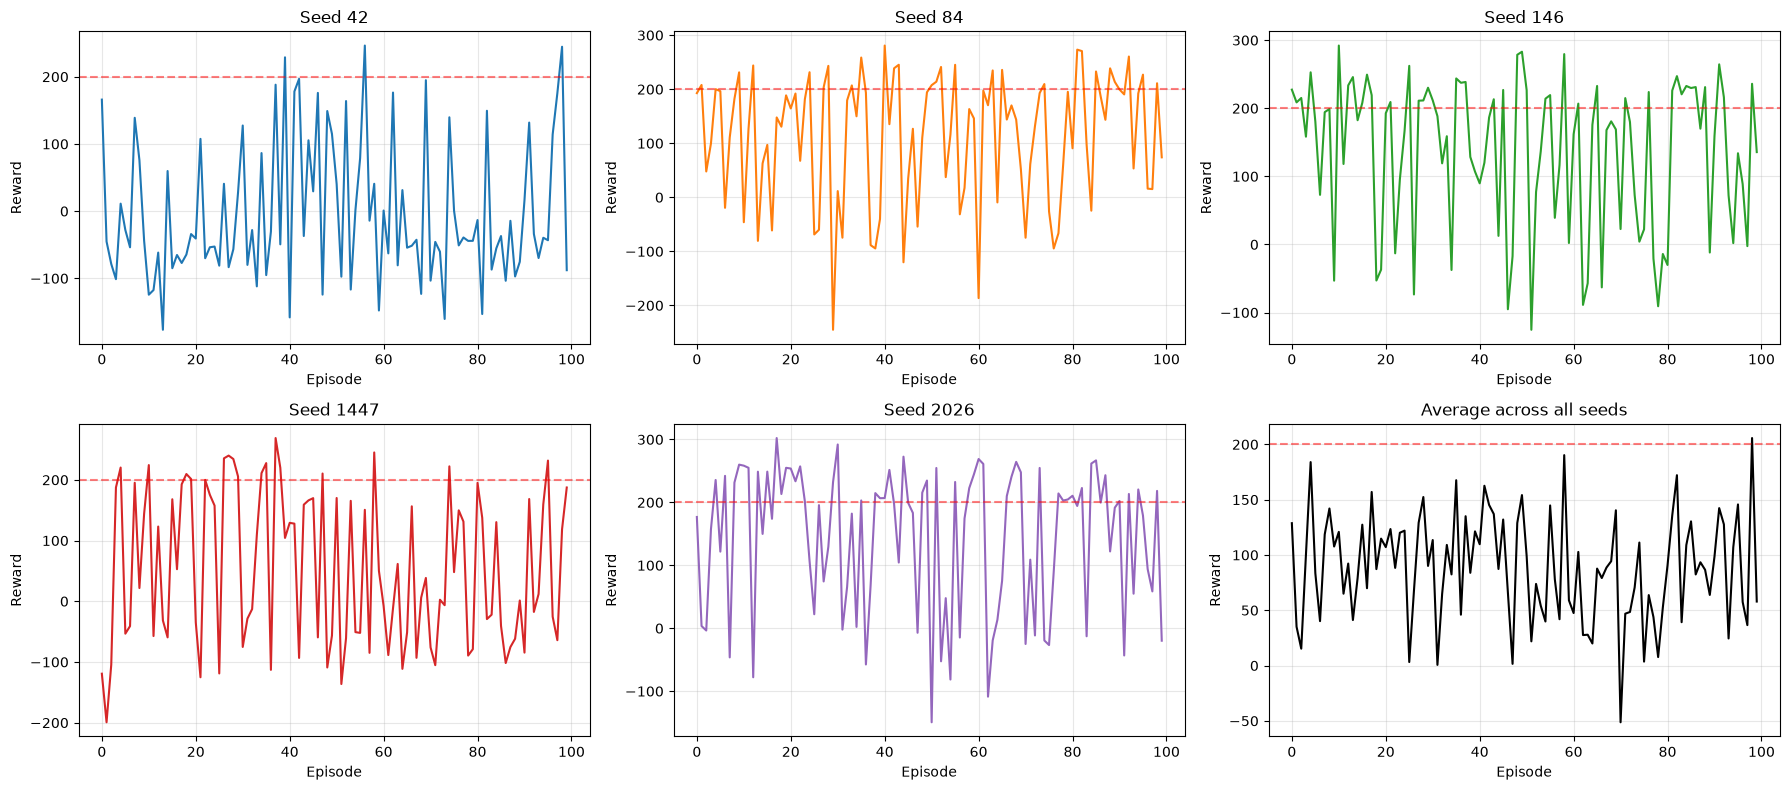

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

seed_names = list(all_test_rewards_data.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, seed_name in enumerate(seed_names):
    rewards = all_test_rewards_data[seed_name]
    axes[i].plot(rewards, color=colors[i])
    axes[i].axhline(y=200, color='red', linestyle='--', alpha=0.5)
    axes[i].set_title(seed_name)
    axes[i].set_xlabel("Episode")
    axes[i].set_ylabel("Reward")
    axes[i].grid(True, alpha=0.3)

avg_rewards = np.mean([all_test_rewards_data[s] for s in seed_names], axis=0)
axes[5].plot(avg_rewards, color='black')
axes[5].axhline(y=200, color='red', linestyle='--', alpha=0.5)
axes[5].set_title("Average across all seeds")
axes[5].set_xlabel("Episode")
axes[5].set_ylabel("Reward")
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

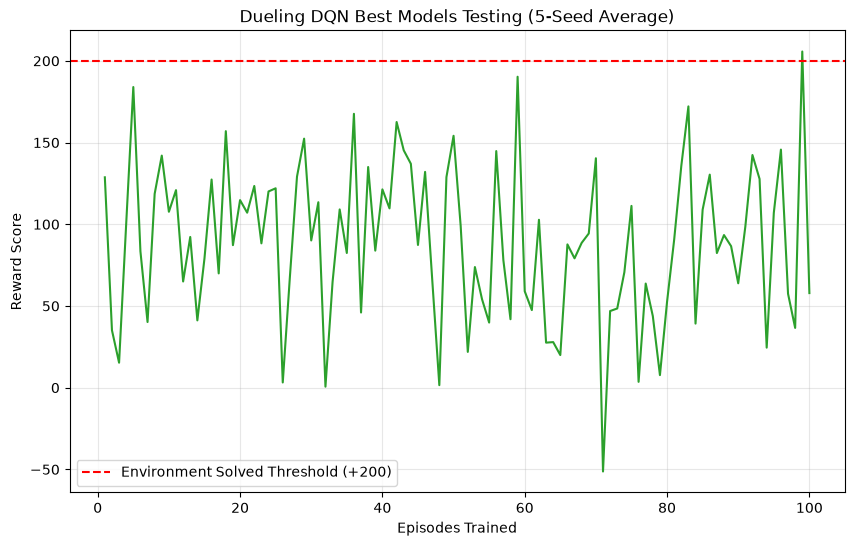

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, NUM_EVAL_EPISODES + 1), avg_rewards, color="tab:green")
plt.axhline(y=200, color="red", linestyle="--", label="Environment Solved Threshold (+200)")
plt.xlabel("Episodes Trained")
plt.ylabel("Reward Score")
plt.title("Dueling DQN Best Models Testing (5-Seed Average)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

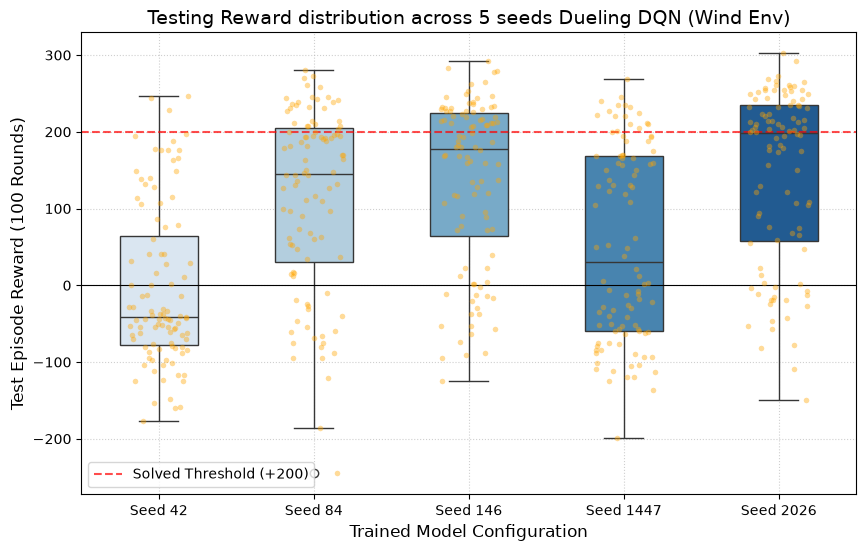

In [15]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=list(all_test_rewards_data.values()), palette="Blues", width=0.5)
sns.stripplot(data=list(all_test_rewards_data.values()), color="orange", alpha=0.4, size=4, jitter=0.2)

plt.xticks(ticks=range(len(final_seeds)), labels=list(all_test_rewards_data.keys()))

plt.axhline(y=200, color='red', linestyle='--', alpha=0.7, label='Solved Threshold (+200)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.title("Testing Reward distribution across 5 seeds Dueling DQN (Wind Env)", fontsize=14)
plt.xlabel("Trained Model Configuration", fontsize=12)
plt.ylabel("Test Episode Reward (100 Rounds)", fontsize=12)
plt.legend(loc="lower left")
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

## Wind Power and Reward Shapping Env

### Model Training

In [ ]:
all_results = []

for seed in final_seeds:
    print(f"\n=== Training Dueling DQN (Wind + Reward Shapping) with seed={seed} ===")

    train_env = gym.make("LunarLander-v3", enable_wind=True, wind_power=15.0, turbulence_power=1.5)
    train_env = DistancePenaltyWrapper(train_env, penalty_weight=0.1)
    train_env = Monitor(train_env, f"wind_reward_shapping_scenario/dueling_dqn/dueling_dqn_seed_{seed}_log")

    eval_env = gym.make("LunarLander-v3", enable_wind=True, wind_power=15.0, turbulence_power=1.5)
    eval_env = DistancePenaltyWrapper(eval_env, penalty_weight=0.1)
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=f"wind_reward_shapping_scenario/dueling_dqn/best_dueling_dqn_seed_{seed}/",
        log_path=f"wind_reward_shapping_scenario/dueling_dqn/eval_logs_seed_{seed}/",
        eval_freq=10_000,
        n_eval_episodes=5,
        deterministic=True
    )

    model = DuelingDQN(
        "MlpPolicy",
        train_env,
        learning_rate=1e-4,
        gamma=0.99,
        exploration_fraction=0.5,
        target_update_interval=1000,
        batch_size= 64,
        buffer_size= 100_000,
        policy_kwargs=dict(net_arch=[128, 128]),
        verbose=0,
        seed=seed,
    )

    model.learn(total_timesteps=1_000_000, callback=eval_callback)
    model.save(f"wind_reward_shapping_scenario/dueling_dqn/dueling_dqn_lunarlander_seed_{seed}")

    best_model = DuelingDQN.load(f"wind_reward_shapping_scenario/dueling_dqn/best_dueling_dqn_seed_{seed}/best_model")
    mean_reward, std_reward = evaluate_policy(best_model, eval_env, n_eval_episodes=20)

    print(f"Seed {seed} -> Best model reward: {mean_reward:.2f} +/- {std_reward:.2f}")
    all_results.append(mean_reward)

all_results = np.array(all_results)
print(f"\n=== Final Result Across {len(final_seeds)} Seeds (Dueling DQN - Wind + Reward Shapping) ===")
print(f"Mean: {all_results.mean():.2f} +/- {all_results.std():.2f}")


=== Training Dueling DQN (Wind + Reward Shapping) with seed=42 ===
Eval num_timesteps=10000, episode_reward=-279.91 +/- 100.58
Episode length: 858.00 +/- 219.21
New best mean reward!
Eval num_timesteps=20000, episode_reward=-349.39 +/- 47.70
Episode length: 643.60 +/- 201.75
Eval num_timesteps=30000, episode_reward=-259.07 +/- 83.00
Episode length: 365.80 +/- 244.37
New best mean reward!
Eval num_timesteps=40000, episode_reward=-239.31 +/- 35.72
Episode length: 416.80 +/- 212.90
New best mean reward!
Eval num_timesteps=50000, episode_reward=-138.00 +/- 91.92
Episode length: 271.40 +/- 88.55
New best mean reward!
Eval num_timesteps=60000, episode_reward=-106.43 +/- 138.96
Episode length: 293.60 +/- 138.65
New best mean reward!
Eval num_timesteps=70000, episode_reward=-121.87 +/- 37.96
Episode length: 205.00 +/- 98.60
Eval num_timesteps=80000, episode_reward=-167.98 +/- 28.82
Episode length: 141.00 +/- 51.17
Eval num_timesteps=90000, episode_reward=-134.55 +/- 39.67
Episode length: 144.

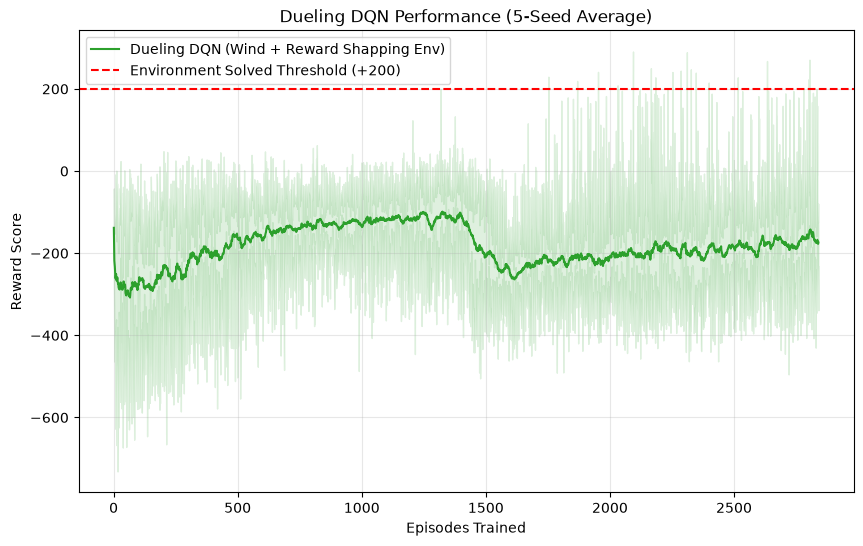

In [ ]:
all_rewards_per_seed = []

for seed in final_seeds:
    data = pd.read_csv(f"wind_reward_shapping_scenario/dueling_dqn/dueling_dqn_seed_{seed}_log.monitor.csv", skiprows=1)
    data['timesteps'] = data['l'].cumsum()
    all_rewards_per_seed.append(data['r'].values)

min_len = min(len(r) for r in all_rewards_per_seed)
all_rewards_per_seed = np.array([r[:min_len] for r in all_rewards_per_seed])

episodes = np.arange(1, min_len + 1)

mean_across_seeds = all_rewards_per_seed.mean(axis=0)
min_across_seeds = all_rewards_per_seed.min(axis=0)
max_across_seeds = all_rewards_per_seed.max(axis=0)

window = 20
mean_smooth = pd.Series(mean_across_seeds).rolling(window, min_periods=1).mean()

plt.figure(figsize=(10, 6))
plt.plot(episodes, mean_smooth, label="Dueling DQN (Wind + Reward Shapping Env)", color="tab:green")
plt.fill_between(episodes, min_across_seeds, max_across_seeds, alpha=0.15, color="tab:green")
plt.axhline(y=200, color="red", linestyle="--", label="Environment Solved Threshold (+200)")
plt.xlabel("Episodes Trained")
plt.ylabel("Reward Score")
plt.title("Dueling DQN Performance (5-Seed Average)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Model Testing

In [16]:
NUM_EVAL_EPISODES = 100

all_seed_mean_rewards = []
all_seed_success_rates = []
all_seed_crash_rates = []

all_test_rewards_data = {}

env = gym.make("LunarLander-v3", wind_power=15.0, turbulence_power=1.5, enable_wind=True)
env = DistancePenaltyWrapper(env, penalty_weight=0.1)

print(" Starting 5-Seed evaluation ...\n")

for seed in final_seeds:
    model_path = f"wind_reward_shapping_scenario/dueling_dqn/best_dueling_dqn_seed_{seed}/best_model.zip"
    model = DuelingDQN.load(model_path, env=env)
    
    seed_rewards = []
    successes = 0
    crashes = 0
    
    for ep in range(NUM_EVAL_EPISODES):
        obs, _ = env.reset()
        done = False
        truncated = False
        total_reward = 0

        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            total_reward += reward

            if done or truncated:
                lander_body = env.unwrapped.lander
                is_game_over = env.unwrapped.game_over
                helipad_x1 = env.unwrapped.helipad_x1
                helipad_x2 = env.unwrapped.helipad_x2
                
                lander_x = lander_body.position.x
                
                on_pad = helipad_x1 <= lander_x <= helipad_x2
                
                if is_game_over or abs(obs[0]) >= 1.0:
                    crashes += 1
                elif (not lander_body.awake) and on_pad:
                    successes += 1

        seed_rewards.append(total_reward)
    
    seed_mean_reward = np.mean(seed_rewards)
    seed_success_rate = (successes / NUM_EVAL_EPISODES) * 100
    seed_crash_rate = (crashes / NUM_EVAL_EPISODES) * 100
    
    all_seed_mean_rewards.append(seed_mean_reward)
    all_seed_success_rates.append(seed_success_rate)
    all_seed_crash_rates.append(seed_crash_rate)
    all_test_rewards_data[f"Seed {seed}"] = seed_rewards
    
    print(f" Seed {seed} raw metrics:")
    print(f"Mean Reward: {seed_mean_reward:.2f}")
    print(f"Success Rate: {seed_success_rate:.1f}%")
    print(f"Crash Rate: {seed_crash_rate:.1f}%\n")

env.close()

final_reward_mean = np.mean(all_seed_mean_rewards)
final_reward_std = np.std(all_seed_mean_rewards)
final_success_mean = np.mean(all_seed_success_rates)
final_crash_mean = np.mean(all_seed_crash_rates)

print(" Final 5-seed metrics averages(Dueling DQN - Reward Shapping + Wind):")
print(f"Overall Mean Reward: {final_reward_mean:.2f} +/- {final_reward_std:.2f}")
print(f"Overall Success Rate: {final_success_mean:.1f}%")
print(f"Overall Crash Rate: {final_crash_mean:.1f}%")

 Starting 5-Seed evaluation ...

 Seed 42 raw metrics:
Mean Reward: 32.80
Success Rate: 34.0%
Crash Rate: 9.0%

 Seed 84 raw metrics:
Mean Reward: 70.46
Success Rate: 29.0%
Crash Rate: 19.0%

 Seed 146 raw metrics:
Mean Reward: -30.67
Success Rate: 20.0%
Crash Rate: 9.0%

 Seed 1447 raw metrics:
Mean Reward: 30.40
Success Rate: 41.0%
Crash Rate: 34.0%

 Seed 2026 raw metrics:
Mean Reward: 95.33
Success Rate: 51.0%
Crash Rate: 3.0%

 Final 5-seed metrics averages(Dueling DQN - Reward Shapping + Wind):
Overall Mean Reward: 39.66 +/- 42.72
Overall Success Rate: 35.0%
Overall Crash Rate: 14.8%


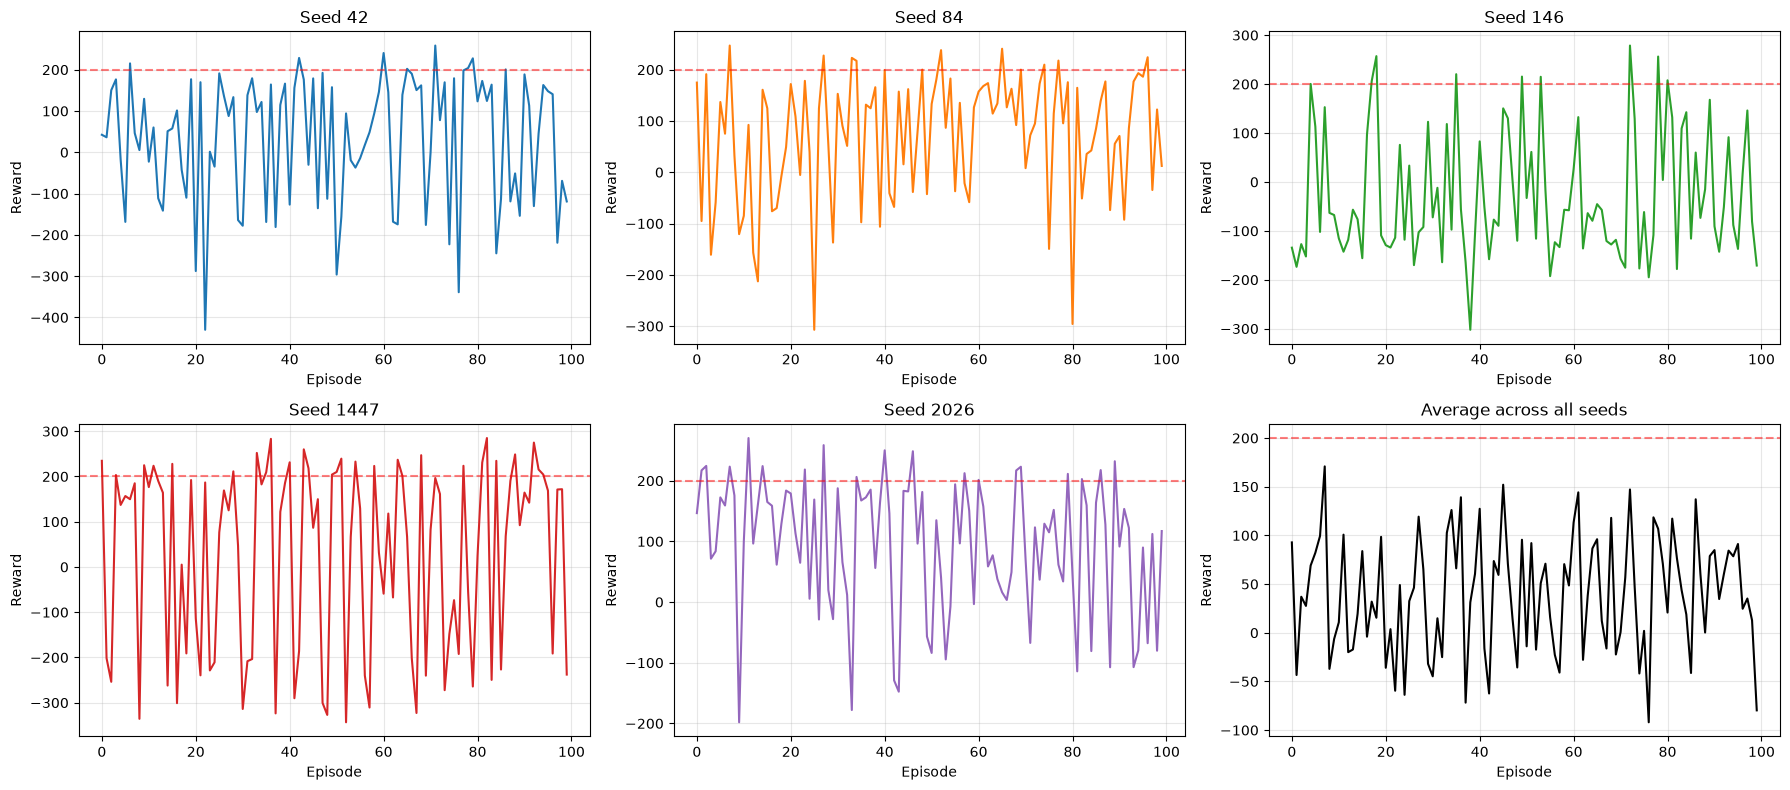

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

seed_names = list(all_test_rewards_data.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, seed_name in enumerate(seed_names):
    rewards = all_test_rewards_data[seed_name]
    axes[i].plot(rewards, color=colors[i])
    axes[i].axhline(y=200, color='red', linestyle='--', alpha=0.5)
    axes[i].set_title(seed_name)
    axes[i].set_xlabel("Episode")
    axes[i].set_ylabel("Reward")
    axes[i].grid(True, alpha=0.3)

avg_rewards = np.mean([all_test_rewards_data[s] for s in seed_names], axis=0)
axes[5].plot(avg_rewards, color='black')
axes[5].axhline(y=200, color='red', linestyle='--', alpha=0.5)
axes[5].set_title("Average across all seeds")
axes[5].set_xlabel("Episode")
axes[5].set_ylabel("Reward")
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

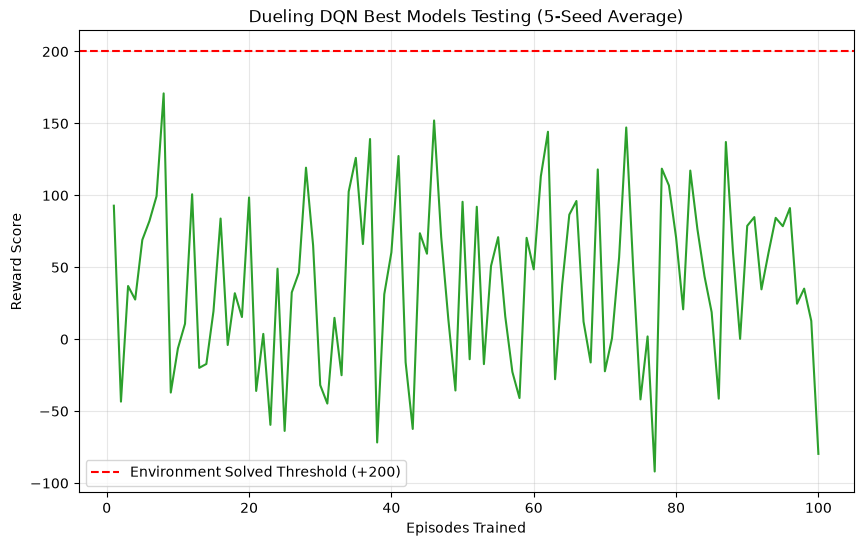

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, NUM_EVAL_EPISODES + 1), avg_rewards, color="tab:green")
plt.axhline(y=200, color="red", linestyle="--", label="Environment Solved Threshold (+200)")
plt.xlabel("Episodes Trained")
plt.ylabel("Reward Score")
plt.title("Dueling DQN Best Models Testing (5-Seed Average)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

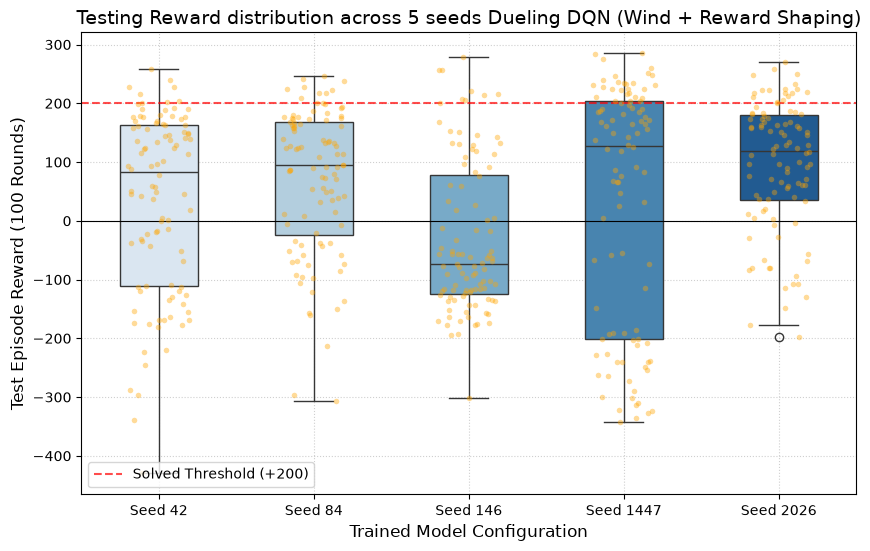

In [19]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=list(all_test_rewards_data.values()), palette="Blues", width=0.5)
sns.stripplot(data=list(all_test_rewards_data.values()), color="orange", alpha=0.4, size=4, jitter=0.2)

plt.xticks(ticks=range(len(final_seeds)), labels=list(all_test_rewards_data.keys()))

plt.axhline(y=200, color='red', linestyle='--', alpha=0.7, label='Solved Threshold (+200)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.title("Testing Reward distribution across 5 seeds Dueling DQN (Wind + Reward Shaping)", fontsize=14)
plt.xlabel("Trained Model Configuration", fontsize=12)
plt.ylabel("Test Episode Reward (100 Rounds)", fontsize=12)
plt.legend(loc="lower left")
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

## Comparative Plots

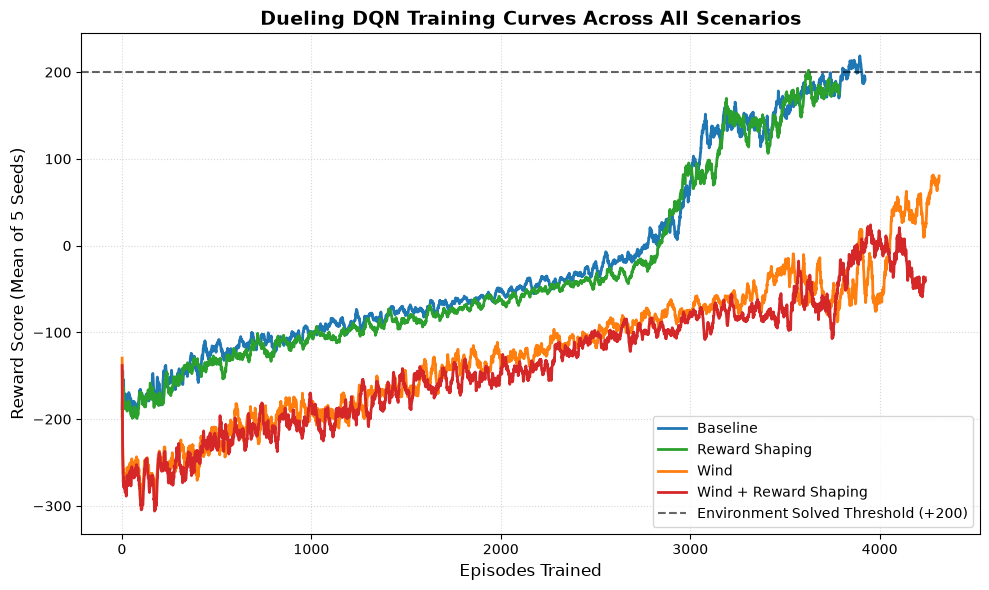

In [20]:
scenarios = {
    "Baseline": "baseline_scenario/dueling_dqn",
    "Reward Shaping": "reward_shpping_scenario/dueling_dqn",
    "Wind": "wind_scenario/dueling_dqn",
    "Wind + Reward Shaping": "wind_reward_shapping_scenario/dueling_dqn",
}

colors = {
    "Baseline": "tab:blue",
    "Reward Shaping": "tab:green",
    "Wind": "tab:orange",
    "Wind + Reward Shaping": "tab:red",
}

plt.figure(figsize=(10, 6))

for scenario_name, folder in scenarios.items():
    all_rewards_per_seed = []

    for seed in final_seeds:
        data = pd.read_csv(f"{folder}/dueling_dqn_seed_{seed}_log.monitor.csv", skiprows=1)
        data['timesteps'] = data['l'].cumsum()
        all_rewards_per_seed.append(data['r'].values)

    min_len = min(len(r) for r in all_rewards_per_seed)
    all_rewards_per_seed = np.array([r[:min_len] for r in all_rewards_per_seed])

    episodes = np.arange(1, min_len + 1)
    mean_across_seeds = all_rewards_per_seed.mean(axis=0)

    window = 20
    mean_smooth = pd.Series(mean_across_seeds).rolling(window, min_periods=1).mean()

    plt.plot(episodes, mean_smooth, label=scenario_name, color=colors[scenario_name], linewidth=2)

plt.axhline(y=200, color="black", linestyle="--", alpha=0.6, label="Environment Solved Threshold (+200)")
plt.xlabel("Episodes Trained", fontsize=12)
plt.ylabel("Reward Score (Mean of 5 Seeds)", fontsize=12)
plt.title("Dueling DQN Training Curves Across All Scenarios", fontsize=14, fontweight="bold")
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()